### Student Information
Name: 吳柏逸

Student ID: 114062553

GitHub ID: Ubereats9481

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas.
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__.

### Second Phase Submission

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__.

# Phase 1

In [ ]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn plotly wordcloud

In [ ]:
### Begin Assignment Here
# Python version: 3.13.7
import pandas as pd
import helpers.data_mining_helpers as dmh
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preparation

In [ ]:
data = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')
data.head()

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          847 non-null    object 
 1   datetime      847 non-null    object 
 2   post_id       847 non-null    object 
 3   subreddit     847 non-null    object 
 4   title         847 non-null    object 
 5   author        847 non-null    object 
 6   url           847 non-null    object 
 7   upvotes       847 non-null    int64  
 8   downvotes     64 non-null     float64
 9   upvote_ratio  64 non-null     float64
 10  text          847 non-null    object 
 11  subjectivity  847 non-null    float64
 12  polarity      847 non-null    float64
 13  sentiment     847 non-null    float64
 14  entities      847 non-null    object 
 15  label         847 non-null    float64
dtypes: float64(6), int64(1), object(9)
memory usage: 106.0+ KB


In [ ]:
# Exercise 1:
# print the first 3 examples
for i in range(3):
    print(f"example {i}")
    print("\n".join(data['text'][i].split("\n")))

example 0
Calls on retards
example 1
Stunt as in like why did they even make a big deal about starting it in the first place? No company should ever talk about politics ever.
example 2
Seeing lots of red in the ticker.


### Data Transformation & Data Mining using Pandas

In [ ]:
# Exercise 2:
print(data.label[0:26:5])
print("----------------")

print([sum(data["label"] == i) for i in range(-1, 2)])  # check how many documents in each category
print("----------------")

print(data.at[0, 'text'])
print("----------------")

print(data.loc[data.index[[0, 10, 20]], ['text', 'label']])
print("----------------")

print(data.sample(3))
print("----------------")

0    -1.0
5     0.0
10    0.0
15    0.0
20   -1.0
25   -1.0
Name: label, dtype: float64
----------------
[315, 423, 109]
----------------
Calls on retards
----------------
                                            text  label
0                               Calls on retards   -1.0
10  It's a copy/paste from a Bloomberg terminal.    0.0
20           Nooo dont go down its smug bull day   -1.0
----------------
        type             datetime  post_id         subreddit  \
593  comment  2025-04-11 14:39:30  mmkjg2n            stocks   
641  comment  2024-12-04 20:46:23  m0fg37e  stockstobuytoday   
788  comment  2025-04-11 14:27:01  mmkgygy            stocks   

                                                 title                author  \
593        Is the market in complete denial right now?  Academic_District224   
641                                    Watchlist 12/04         ITProGuidance   
788  r/Stocks Daily Discussion & Fundamentals Frida...     gary_oldman_sachs   

         

In [ ]:
# Exercise 3:
data[data.label == 1][::10][:5]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
78,comment,2025-04-11 15:11:59,mmkq0pj,StockMarket,$ U.S. dollar value (crashing),AdQuick8612,https://i.redd.it/atvlo83gk4ue1.jpeg,1,NaN,NaN,I think it’s gonna work itself out. I bought t...,0.133333,-0.133333,-1.0,"['trading', 'app', 'gloom', 'doom', 'gon']",1.0
168,comment,2025-04-11 13:09:51,mmk2ho9,stocks,r/Stocks Daily Discussion & Fundamentals Frida...,mazzaschi,https://www.reddit.com/r/stocks/comments/1jwlr...,1,NaN,NaN,The obvious can also be refreshing from CNBC: ...,0.750000,0.250000,1.0,"['bond', 'U.S', 'dollar', '’', 'Fed', 'CNBC', ...",1.0
219,comment,2023-08-12 2:20:58,jvtj2dl,stockstobuytoday,APLS stocks,muffins95,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,Same. Back to break even after that last rip b...,0.300000,0.144444,1.0,"['rip', 'Same', 'Back', '%', 'thing']",1.0
319,comment,2021-02-01 14:44:17,gllpzay,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",inuvash255,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Etrade has a feed of news articles about how r...,0.000000,0.000000,0.0,"['news', 'actual-reddit', 'reddit', 'GME', 'Et...",1.0


In [ ]:
data.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0,0,0,783,783,0,0,0,0,0,0


In [ ]:
# Exercise 4:
data.isnull().apply(lambda x: dmh.check_missing_values(x), axis=1)

0      (The amoung of missing records is: , 2)
1      (The amoung of missing records is: , 2)
2      (The amoung of missing records is: , 2)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 2)
                        ...                   
842    (The amoung of missing records is: , 2)
843    (The amoung of missing records is: , 2)
844    (The amoung of missing records is: , 0)
845    (The amoung of missing records is: , 2)
846    (The amoung of missing records is: , 2)
Length: 847, dtype: object

In [ ]:
print(data.duplicated().sum())  # no duplicates

0


### Data Preprocessing

In [ ]:
data_sample = data.sample(n=300, random_state=42)

label
 0.0    423
-1.0    315
 1.0    109
Name: count, dtype: int64


<Axes: title={'center': 'Label distribution'}, xlabel='label'>

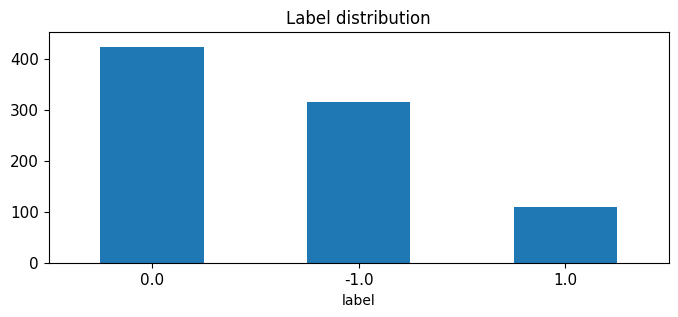

In [ ]:
# Exercise 7:
print(data['label'].value_counts())
data.label.value_counts().plot(kind = 'bar',
                                    title = 'Label distribution',
                                    ylim = [0, data.label.value_counts().max() + 30],
                                    rot = 0, fontsize = 11, figsize = (8,3))

<Axes: title={'center': 'Label distribution'}, xlabel='label'>

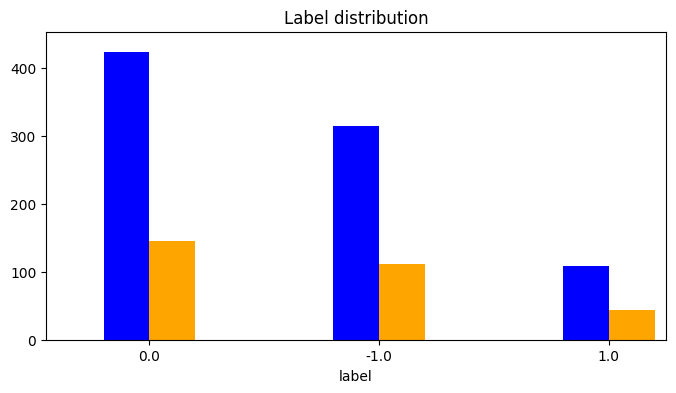

In [ ]:
# Exercise 8:
data_sample.label.value_counts().plot(kind = 'bar', width=0.2,
                                           title = 'Label distribution',
                                           ylim = [0, data.label.value_counts().max()+30],
                                           rot = 0, fontsize = 10, figsize = (8,4), color="orange", position=0)
data.label.value_counts().plot(kind = 'bar', width=0.2,
                                    title = 'Label distribution',
                                    ylim = [0, data.label.value_counts().max()+30],
                                    rot = 0, fontsize = 10, figsize = (8,4), color="blue", position=1)

#### Feature Creation

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\allen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\allen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
data['unigrams'] = data['text'].apply(lambda x: dmh.tokenize_text(x))

In [ ]:
data[0:4]["unigrams"]

0                                 [Calls, on, retards]
1    [Stunt, as, in, like, why, did, they, even, ma...
2          [Seeing, lots, of, red, in, the, ticker, .]
3    [Vision, Marine, Technologies, Inc., is, rewri...
Name: unigrams, dtype: object

#### Feature Subset Selection

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
data_counts = count_vect.fit_transform(data.text) #learn the vocabulary and return document-term matrix
print(data_counts[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 4346)>
  Coords	Values
  (0, 692)	1
  (0, 2706)	1
  (0, 3248)	1


In [ ]:
print(count_vect.get_feature_names_out()[692])
print(count_vect.get_feature_names_out()[2706])
print(count_vect.get_feature_names_out()[3248])


calls
on
retards


In [ ]:
# Exercise 9:
analyze = count_vect.build_analyzer()
analyze(data.text[0])

['calls', 'on', 'retards']

In [ ]:
data_counts[0:30, 0:20].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# Exercise 10:
print(data["text"][3])  # use index n to find the token "116"
n = np.where(data_counts[3, 0:20].toarray() == 3)[-1][-1]  # find the index of 3
count_vect.get_feature_names_out()[n]

Vision Marine Technologies Inc. is rewriting the watercraft rulebook. Their collaboration with Shaun Torrente has achieved the unthinkable – a blazing 116 mph on water! This isn't just about speed; it's about propelling electric boating into a new era. Their cutting-edge technology, combined with Torrente's skill, is making waves that'll ripple for generations.

**Highlight Main Points**

* Vision Marine Technologies Inc. achieves a record-breaking 116 mph speed on water with Shaun Torrente.
* The feat highlights the power of electric boating and pushes the limits of innovation.
* Partners like Octillion Power Systems and Danfoss Editron contribute to this groundbreaking achievement.

**TLDR**

Hold onto your seats – Vision Marine Technologies Inc. and Shaun Torrente have shattered the water-speed record at an astonishing 116 mph!  This isn't just about speed; it's about pioneering electric boating and innovation. The collaboration of technology, skill, and passion is creating ripples 

'116'

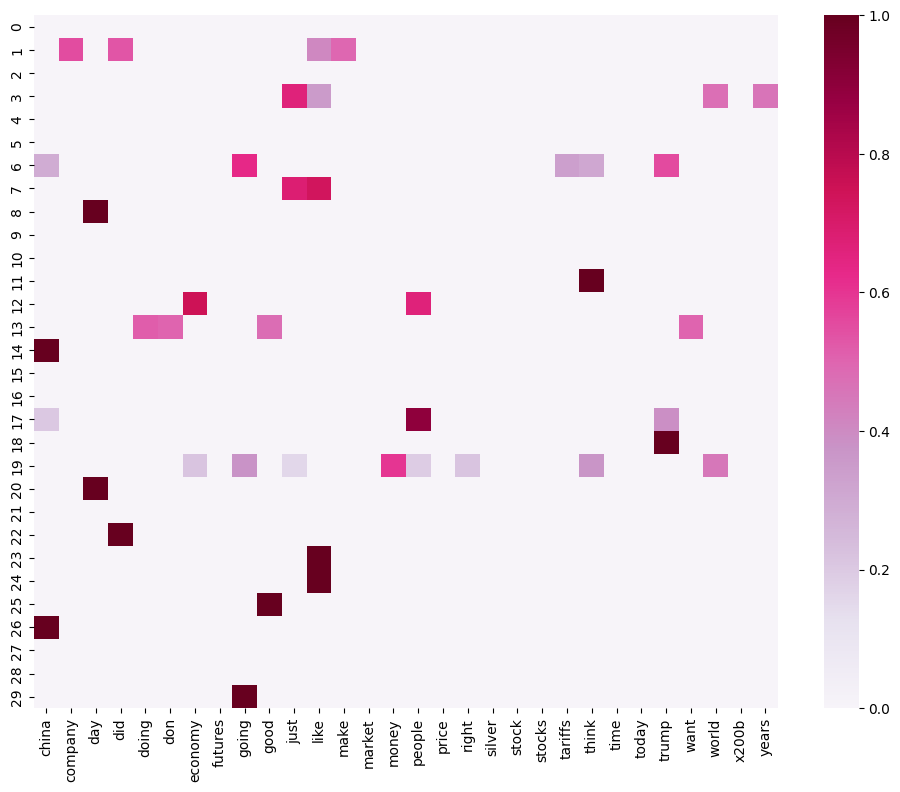

In [ ]:
# Exercise 11:
from sklearn.feature_extraction.text import TfidfVectorizer

# Calculate TF-IDF matrix (try to find important words)
# 30 most important words, remove english stop words (e.g., is, the, a, ...)
vectorizer = TfidfVectorizer(max_features=30, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(data.text)

# show 0 ~ 29 documents and their tf-idf values for each term
terms = vectorizer.get_feature_names_out()
df_todraw = pd.DataFrame(tfidf_matrix[:30, :].toarray(), columns=terms)

plt.subplots(figsize=(12, 9))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=False)

# Discussion: Reddit posts are so short and sparse that even the most commonly used words might not appear in most posts.

In [ ]:
term_frequencies = []
for j in range(0,data_counts.shape[1]):
    term_frequencies.append(sum(data_counts[:,j].toarray()))
term_frequencies = np.asarray(data_counts.sum(axis=0))[0]

In [ ]:
# Exercise 12:
import plotly.express as px

fig = px.bar(
    x=count_vect.get_feature_names_out()[:300],
    y=term_frequencies[:300],
    labels={'x': 'Term', 'y': 'Frequency'},
)
fig.show()

In [ ]:
# Exercise 13 & 14 (Two exercises' code are the same):
# calculate term frequencies for all terms
all_terms = count_vect.get_feature_names_out()
df_freq = pd.DataFrame({
    'Term': all_terms,
    'Frequency': term_frequencies
})
# choose top 100 terms
df_sorted = df_freq.sort_values(by='Frequency', ascending=False).head(100)

fig = px.bar(
    data_frame=df_sorted,
    x='Term',
    y='Frequency',
    labels={'Term': 'Term', 'Frequency': 'Frequency'},
)

fig.show()

In [ ]:
# Exercise 15:
import math
term_frequencies_log = [math.log(i) for i in term_frequencies]
# calculate term frequencies for all terms
all_terms = count_vect.get_feature_names_out()
df_freq = pd.DataFrame({
    'Term': all_terms,
    'Frequency': term_frequencies_log
})
# choose top 100 terms
df_sorted = df_freq.sort_values(by='Frequency', ascending=False).head(100)

fig = px.bar(
    data_frame=df_sorted,
    x='Term',
    y='Frequency',
    labels={'Term': 'Term', 'Frequency': 'Frequency'},
)

fig.show()

### Generate meaningful new data visualizations.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\allen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


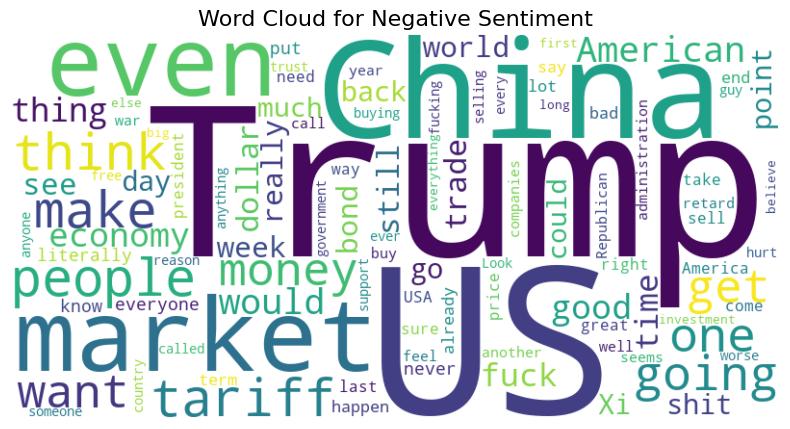

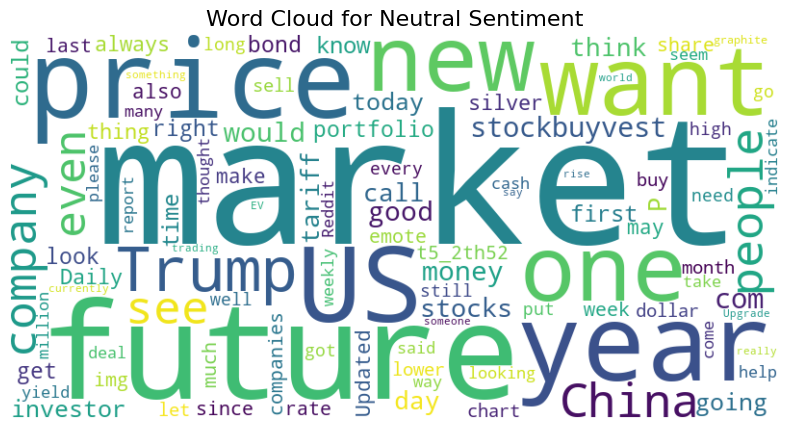

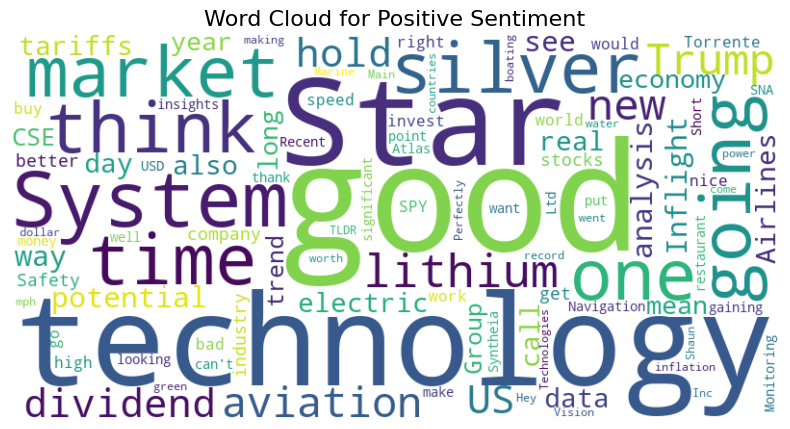

In [ ]:
# Visualization 1: Wordcloud for each label (Ref: NLP course)
from wordcloud import WordCloud
from nltk.corpus import stopwords

# Get English stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Add custom stopwords specific to Reddit/stock discussions
custom_stopwords = {'stock', 'like', 'U', 'x200B'}
stop_words.update(custom_stopwords)

labels = {-1: "Negative", 0: "Neutral", 1: "Positive"}
for label in labels.keys():
    text = " ".join(data[data.label == label].text)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words,  # Remove stopwords
        max_words=100,
        collocations=False,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {labels[label]} Sentiment', fontsize=16)
    plt.axis('off')
    plt.show()

* We can see that for negative posts, "China", "Trump", "US" are the most common words, it is possible that these words have appeared significantly in negative posts due to the market volatility caused by the US-China confrontation and Trump's various policies in recent years.
* For neutral posts, "market", "price", "future" are the most common words, which are just common words in posts on the stock subreddit.
* For positive posts, "good", "technology", "star" are the most common words, in addition to general positive words, there are also some popular field words in recent years.

In [ ]:
# Visualization 2: Boxplot of upvotes by sentiment category

# Remove outliers for better visualization
quantile_99 = data['upvotes'].quantile(0.99)
# Because over 50% of posts have 1 upvote, we filter out those with 1 or fewer upvotes
data_filtered = data[(data['upvotes'] > 1) & (data['upvotes'] < quantile_99)]

data_viz = data_filtered.copy()
data_viz['Sentiment'] = data_viz['label'].map({-1: 'Negative', 0: 'Neutral', 1: 'Positive'})
# Use log scale for upvotes to reduce skewness
data_viz['upvotes'] = [math.log(i) for i in data_viz['upvotes']]

# Draw boxplot
fig = px.box(data_viz,
             x='Sentiment',
             y='upvotes',
             color='Sentiment',
             title='Distribution of Upvotes by Sentiment (Log Scale)',
             labels={'upvotes': 'Number of Upvotes', 'Sentiment': 'Sentiment Label'},
             color_discrete_map={'Negative': '#ff6b6b', 'Neutral': '#95a5a6', 'Positive': '#51cf66'})
fig.show()

# Print summary statistics
print("----------------------------------------------------------------")
print("Upvotes Summary Statistics by Sentiment (Log Scale):")
print(data_viz.groupby('label')['upvotes'].describe())

----------------------------------------------------------------
Upvotes Summary Statistics by Sentiment (Log Scale):
       count      mean       std       min       25%       50%       75%  \
label                                                                      
-1.0   146.0  1.841578  1.010038  0.693147  0.693147  1.791759  2.564949   
 0.0   163.0  1.695867  0.998683  0.693147  0.693147  1.386294  2.397895   
 1.0    47.0  1.813178  1.093878  0.693147  0.693147  1.386294  2.484907   

            max  
label            
-1.0   4.406719  
 0.0   4.382027  
 1.0   4.007333  


In the raw data, I found that over half of the upvotes were 1, making it difficult to discern the overall trend. Therefore, I applied some filtering to this area.
Based on the boxplot, I observed that negative posts often had more upvotes than positive and neutral posts. This suggests that negative posts in the data are more likely to evoke user engagement.

# Phase 2

In [ ]:
### Begin Assignment Here